Citation Request:
  This dataset is public available for research. The details are described in [Moro et al., 2011].
  Please include this citation if you plan to use this database:

  [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, GuimarÃ£es, Portugal, October, 2011. EUROSIS.

  Available at: [pdf] http://hdl.handle.net/1822/14838
                [bib] http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt

1. Title: Bank Marketing

2. Sources
   Created by: Paulo Cortez (Univ. Minho) and SÃ©rgio Moro (ISCTE-IUL) @ 2012
   
3. Past Usage:

  The full dataset was described and analyzed in:

  S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, GuimarÃ£es,
  Portugal, October, 2011. EUROSIS.

4. Relevant Information:

   The data is related with direct marketing campaigns of a Portuguese banking institution.
   The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required,
   in order to access if the product (bank term deposit) would be (or not) subscribed.

   The classification goal is to predict if the client will subscribe a term deposit (variable y).

5. Number of Instances: 9000

6. Number of Attributes: 16 + output attribute.

7. Attribute information:

   For more information, read [Moro et al., 2011].

   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric)
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")


# 4.	Incluye las librerías que consideres adecuadas y carga los datos del archivo en una variable llamada “data”.

In [24]:
# Librerías base que utilizaré para el manejo y resolución de los puntos 4 y 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para resolver los puntos 6 al 12
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [25]:
data = pd.read_csv('/content/sample_data/bank_marketing.csv')
data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


In [26]:
# Ejectuto esta primera línea para ver dimensiones y primeras filas
print("Shape:", data.shape)
display(data.head())

# Identifico tipos y nulos
data.info()
print(data.isnull().sum())

# Elaboro un resumen estadístico que me pue3de servir para identificar las medidas más relevantes que puedan ser complementarias
# al análisis más complejo de entrenamiento y a su vez me ayuda a identificar las categóricas y
# las numéricas de manera sencillas y visual al ver las que en dichas medidas muestran el NaN
display(data.describe(include='all').T)


Shape: (9000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB
age          0
job          0
marital      0
education    0
default      0
balance      0
housing    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,9000.0,NaN,NaN,NaN,41.090556,11.664253,18.0,32.0,39.0,49.0,95.0
job,9000,12,management,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,9000,3,married,5124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,9000,4,secondary,4486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,9000,2,no,8865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,9000.0,NaN,NaN,NaN,1482.262778,3031.013197,-3058.0,109.0,519.0,1646.5,81204.0
housing,9000,2,no,4564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,9000,2,no,7820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,9000,3,cellular,6438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,9000.0,NaN,NaN,NaN,15.619556,8.345305,1.0,8.0,15.0,21.0,31.0


# 5.	Obtener la información de dicha base de datos que incluya el número de registros, el total de variables, el tipo de cada variable, la cantidad de datos perdidos de cada variable en caso de que existan.

In [27]:
# Defino algunas opciones de visualización que me han funcionado en otros códigos al ser una base de las dimensiones que se muestran
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 200)

Normalizar valores que podrían representar faltantes y crear copia de trabajo

In [28]:
# Defino una lista de representación de valores que falten para que pandas trate todas esas formas de "missing" como NaN,
# lo que permite contarlos, imputarlos o eliminarlos correctamente en pasos posteriores.
# Se trabaja sobre una copia (data_clean) para no modificar el DataFrame original.
missing_tokens = ['', ' ', 'NA', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None', '?', 'unknown', 'Unknown']

# Reemplazar en una copia (para no alterar el original inmediatamente)
data_clean = data.replace(missing_tokens, np.nan)


Número de registros y total de variables

In [29]:
# Uso data_clean.shape[0] para saber cuántas filas tiene el DataFrame; así
# conozco cuántos registros (clientes/casos) voy a analizar. Uso
# data_clean.shape[1] para conocer cuántas columnas hay; así sé cuántas
# variables debo transformar y evaluar.
# Si bien ya tenía este dato, es una práctica que vale la pena usar y mencionar
n_registros = data_clean.shape[0]
n_variables = data_clean.shape[1]

print(f"Número de registros: {n_registros}")
print(f"Total de variables: {n_variables}")


Número de registros: 9000
Total de variables: 17


Tipo de cada variable (dtype) y resumen rápido

In [30]:
# Muestro el tipo de dato de cada columna, cuántos valores no faltan y cuánta memoria usa cada variable para entender formato y tamaño del dataset.
# Con eso decido qué columnas son categóricas o numéricas y si debo imputar
# nulos u optimizar memoria
dtypes = data_clean.dtypes.to_frame(name='dtype')
dtypes['non_null_count'] = data_clean.notnull().sum().values
dtypes['memory_usage_kb'] = [round(data_clean[col].memory_usage(deep=True)/1024,2) for col in data_clean.columns]

display(dtypes)


,dtype,non_null_count,memory_usage_kb
age,int64,9000,70.44
job,object,8949,512.07
marital,object,9000,490.56
education,object,8623,495.07
default,object,9000,448.50
balance,int64,9000,70.44
housing,object,9000,452.70
loan,object,9000,449.52
contact,object,7018,453.28
day,int64,9000,70.44


Cantidad y porcentaje de datos perdidos por variable

In [31]:
# Calculo cuántos valores faltan por columna y guardo ese conteo en
# missing_counts, además agrego la columna con el porcentaje respecto al total
# de registros. Los ordeno de mayor a menor y muestro la tabla para identificar
# rápidamente qué variables requieren imputación, eliminación o un
# tratamiento especial durante el preprocesado.

missing_counts = data_clean.isnull().sum().to_frame(name='missing_count')
missing_counts['missing_pct'] = (missing_counts['missing_count'] / n_registros * 100).round(2)
missing_counts = missing_counts.sort_values('missing_count', ascending=False)
display(missing_counts)


,missing_count,missing_pct
poutcome,6783,75.37
contact,1982,22.02
education,377,4.19
job,51,0.57
age,0,0.00
default,0,0.00
balance,0,0.00
housing,0,0.00
marital,0,0.00
loan,0,0.00


Resumen consolidado: nombre, tipo, nulos, % nulos, únicos y ejemplos

In [32]:
# Creo un DataFrame llamado summary que reúne, por cada columna, su nombre,
# tipo, conteos de nulos y no nulos, % de nulos, número de valores únicos y
# hasta 5 ejemplos; es una vista compacta del dataset. Uso esa tabla ordenada
# por nulos para identificar rápidamente columnas problemáticas (muchos NaN),
# evaluar cardinalidad y decidir estrategias de imputación y encoding para el
# preprocesado.

summary = pd.DataFrame({
    'column': data_clean.columns,
    'dtype': data_clean.dtypes.values,
    'non_null': data_clean.notnull().sum().values,
    'missing_count': data_clean.isnull().sum().values,
})
summary['missing_pct'] = (summary['missing_count'] / n_registros * 100).round(2)
summary['n_unique'] = [data_clean[col].nunique(dropna=True) for col in data_clean.columns]
summary['sample_values'] = [data_clean[col].dropna().unique()[:5].tolist() for col in data_clean.columns]

# Ordena por % de missing descendente
summary = summary.sort_values('missing_count', ascending=False).reset_index(drop=True)
display(summary)


,column,dtype,non_null,missing_count,missing_pct,n_unique,sample_values
0,poutcome,object,2217,6783,75.37,3,"[success, failure, other]"
1,contact,object,7018,1982,22.02,2,"[cellular, telephone]"
2,education,object,8623,377,4.19,3,"[tertiary, secondary, primary]"
3,job,object,8949,51,0.57,11,"[self-employed, unemployed, blue-collar, admin., retired]"
4,age,int64,9000,0,0.00,74,"[31, 29, 41, 50, 40]"
5,default,object,9000,0,0.00,2,"[no, yes]"
6,balance,int64,9000,0,0.00,3476,"[2666, 1584, 2152, 84, 0]"
7,housing,object,9000,0,0.00,2,"[no, yes]"
8,marital,object,9000,0,0.00,3,"[married, single, divorced]"
9,loan,object,9000,0,0.00,2,"[no, yes]"


Ver columnas categóricas y numéricas (lista) — útil para el preprocesado posterior

In [33]:
# Identifico las columnas categóricas y numéricas usando tipos de pandas para
# saber qué variables necesitan encoding (categorías) o escalado/imputación
# (numéricas). Imprimo la cantidad y la lista de cada tipo para planear el
# preprocesado.

cat_cols = data_clean.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = data_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Columnas categóricas:", len(cat_cols), cat_cols)
print("Columnas numéricas:", len(num_cols), num_cols)


Columnas categóricas: 10 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Columnas numéricas: 7 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


(Opcional) Tabla de frecuencias para las columnas categóricas principales

In [34]:
# Imprimo las 10 categorías más frecuentes (incluyendo NaN) de las primeras
# seis columnas categóricas para inspeccionar rápidamente su distribución y
# detectar valores atípicos o representaciones de faltantes. Con esa
# información decido si agrupar categorías raras, imputar valores o elegir el
# encoding más apropiado (LabelEncoder o OneHotEcoder) para cada columna.

for col in cat_cols[:6]:
    print("=== Col:", col, "===\n")
    print(data_clean[col].value_counts(dropna=False).head(10))
    print("\n")


=== Col: job ===

job
management       1999
blue-collar      1688
technician       1485
admin.           1004
services          771
retired           594
self-employed     319
student           312
unemployed        290
housemaid         246
Name: count, dtype: int64


=== Col: marital ===

marital
married     5124
single      2837
divorced    1039
Name: count, dtype: int64


=== Col: education ===

education
secondary    4486
tertiary     2893
primary      1244
NaN           377
Name: count, dtype: int64


=== Col: default ===

default
no     8865
yes     135
Name: count, dtype: int64


=== Col: housing ===

housing
no     4564
yes    4436
Name: count, dtype: int64


=== Col: loan ===

loan
no     7820
yes    1180
Name: count, dtype: int64




# 6.	Transforma las variables categóricas de manera que puedan ser tratadas numéricamente. Justifica si utilizas LabelEncoder o OneHotEcoder.

In [34]:
# He identificado las variables categóricas del dataset y voy a transformarlas
# para que los modelos las puedan usar
# como números. Concretamente:

# Transformo default, housing y loan (binarias yes/no) a 0/1 porque son binarias y ese mapeo es simple, interpretable y eficiente.
# Transformo education como ordinal (primary < secondary < tertiary) usando un codificador ordinal porque existe un orden lógico entre niveles.
# Imputo los NaN con la moda del conjunto de entrenamiento antes de codificar.
# Transformo job y marital como nominales mediante OneHotEncoder porque no
# tienen orden y así evito imponer un orden artificial que dañaría la
# Regresión Logística y la Red Neuronal.

# Decisión LabelEncoder vs OneHotEncoder:

# No uso LabelEncoder para variables nominales porque asigna enteros que
# introducen orden artificial. Uso OneHotEncoder para nominales de baja
# cardinalidad (regresión y NN). Para la Regresión Logística aplico
# OneHotEncoder(drop='first') para evitar multicolinealidad; para la Red
# Neuronal no dropearé las dummies (o podría usar embeddings si hubiese alta
# cardinalidad).


In [36]:
df = data_clean.copy()   # data_clean ya tiene tokens de missing normalizados a np.nan

In [37]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# Variables que ya inspeccionaste (ajusta si tu df tiene nombres distintos)
cols_focus = ['job', 'marital', 'education', 'default', 'housing', 'loan']
cols_focus = [c for c in cols_focus if c in df.columns]
print("Columnas foco:", cols_focus)


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Columnas foco: ['job', 'marital', 'education', 'default', 'housing', 'loan']


In [38]:
# Convertir target 'y' a binaria si es necesario
if 'y' in df.columns:
    df['y'] = df['y'].map({'yes':1, 'no':0})

X = df.drop(columns=['y']) if 'y' in df.columns else df.copy()
y = df['y'] if 'y' in df.columns else None

# Split 60/20/20
if y is not None:
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
else:
    X_train, X_temp = train_test_split(X, test_size=0.4, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)


In [39]:
# Umbral para considerar "alta cardinalidad"
HIGH_CARD_THRESH = 10

# detectar binarias (2 categorías)
binary_cols = [c for c in X_train.select_dtypes(include=['object','category']).columns
               if X_train[c].nunique(dropna=True) == 2]

# si sabes que 'education' es ordinal, lo indicamos explicitamente
ordinal_cols = [c for c in ['education'] if c in X_train.columns]

# restantes candidatas a one-hot (excluye binarias y ordinales)
onehot_candidates = [c for c in X_train.select_dtypes(include=['object','category']).columns
                     if c not in binary_cols + ordinal_cols]

onehot_cols = [c for c in onehot_candidates if X_train[c].nunique(dropna=True) <= HIGH_CARD_THRESH]
high_card_cols = [c for c in onehot_candidates if X_train[c].nunique(dropna=True) > HIGH_CARD_THRESH]

print("Binary:", binary_cols)
print("Ordinal:", ordinal_cols)
print("One-hot (low-card):", onehot_cols)
print("High-cardinality:", high_card_cols)


Binary: ['default', 'housing', 'loan', 'contact']
Ordinal: ['education']
One-hot (low-card): ['marital', 'poutcome']
High-cardinality: ['job', 'month']


In [40]:
binary_map = {'yes':1, 'no':0}

for col in binary_cols:
    mode = X_train[col].mode(dropna=True)[0]
    # imputar con moda del train y mapear en train/val/test
    X_train[col] = X_train[col].fillna(mode).map(binary_map)
    X_val[col]   = X_val[col].fillna(mode).map(binary_map)
    X_test[col]  = X_test[col].fillna(mode).map(binary_map)


In [41]:
if 'education' in ordinal_cols:
    edu_mode = X_train['education'].mode(dropna=True)[0]
    X_train['education'] = X_train['education'].fillna(edu_mode)
    X_val['education']   = X_val['education'].fillna(edu_mode)
    X_test['education']  = X_test['education'].fillna(edu_mode)

    # definir orden explícito (ajustar según bank-names.txt si fuera distinto)
    edu_order = ['primary', 'secondary', 'tertiary']
    ord_enc = OrdinalEncoder(categories=[edu_order], dtype=np.int64,
                             handle_unknown='use_encoded_value', unknown_value=-1)
    ord_enc.fit(X_train[['education']])
    X_train['education_ord'] = ord_enc.transform(X_train[['education']]).astype(int)
    X_val['education_ord']   = ord_enc.transform(X_val[['education']]).astype(int)
    X_test['education_ord']  = ord_enc.transform(X_test[['education']]).astype(int)

    # eliminar la columna textual original si lo deseas
    X_train = X_train.drop(columns=['education'])
    X_val   = X_val.drop(columns=['education'])
    X_test  = X_test.drop(columns=['education'])


In [44]:
# Para Regresión Logística: drop='first' (evita dummy trap)
ohe_log = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

# Ajustar sólo con los datos de entrenamiento
if onehot_cols:
    ohe_log.fit(X_train[onehot_cols])

    ohe_cols = ohe_log.get_feature_names_out(onehot_cols).tolist()

    X_train_ohe = pd.DataFrame(ohe_log.transform(X_train[onehot_cols]), columns=ohe_cols, index=X_train.index)
    X_val_ohe   = pd.DataFrame(ohe_log.transform(X_val[onehot_cols]),   columns=ohe_cols, index=X_val.index)
    X_test_ohe  = pd.DataFrame(ohe_log.transform(X_test[onehot_cols]),  columns=ohe_cols, index=X_test.index)

    # eliminar originales y concatenar
    X_train = pd.concat([X_train.drop(columns=onehot_cols), X_train_ohe], axis=1)
    X_val   = pd.concat([X_val.drop(columns=onehot_cols),   X_val_ohe],   axis=1)
    X_test  = pd.concat([X_test.drop(columns=onehot_cols),  X_test_ohe],  axis=1)


In [45]:
def frequency_encode_col(train, val, test, col):
    freq = train[col].fillna('missing').value_counts(normalize=True)
    train_enc = train[col].fillna('missing').map(freq).astype(float)
    val_enc   = val[col].fillna('missing').map(freq).fillna(0.0).astype(float)
    test_enc  = test[col].fillna('missing').map(freq).fillna(0.0).astype(float)
    return train_enc, val_enc, test_enc

for col in high_card_cols:
    X_train[col + '_freq'], X_val[col + '_freq'], X_test[col + '_freq'] = frequency_encode_col(X_train, X_val, X_test, col)
    # eliminar la columna original textual
    X_train = X_train.drop(columns=[col])
    X_val   = X_val.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])


In [47]:
# detectar columnas numéricas finales
num_final = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
scaler.fit(X_train[num_final])

X_train[num_final] = scaler.transform(X_train[num_final])
X_val[num_final]   = scaler.transform(X_val[num_final])
X_test[num_final]  = scaler.transform(X_test[num_final])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [48]:
print("Shapes finales:", X_train.shape, X_val.shape, X_test.shape)
display(X_train.head())


Shapes finales: (5400, 19) (1800, 19) (1800, 19)


,age,default,balance,housing,loan,contact,day,duration,campaign,pdays,previous,education_ord,marital_married,marital_single,poutcome_other,poutcome_success,poutcome_nan,job_freq,month_freq
214,0.845346,-0.120273,-0.137350,1.015678,-0.384655,NaN,1.715246,-0.320013,-0.185943,-0.468119,-0.333965,-0.268530,-1.147433,-0.682203,-0.229863,-0.301877,0.559954,0.708877,1.499182
3327,-0.446184,-0.120273,0.158157,1.015678,2.599735,NaN,-0.320194,-0.536140,-0.555367,2.934436,0.528086,-1.801367,0.871511,-0.682203,4.350425,-0.301877,-1.785859,0.708877,1.499182
3655,-1.134999,-0.120273,-0.479230,1.015678,-0.384655,NaN,1.356051,-0.767071,-0.555367,2.064894,0.097061,-0.268530,-1.147433,1.465840,-0.229863,-0.301877,-1.785859,0.338537,-1.354688
1213,-0.876693,-0.120273,-0.388723,1.015678,2.599735,NaN,1.595515,-0.941749,0.183481,-0.468119,-0.333965,-0.268530,0.871511,-0.682203,-0.229863,-0.301877,0.559954,0.708877,1.499182
5952,-1.651611,-0.120273,-0.420064,-0.984564,-0.384655,NaN,-0.918853,-0.598314,-0.555367,-0.468119,-0.333965,-0.268530,-1.147433,1.465840,-0.229863,-0.301877,0.559954,-1.605750,0.080270


### 7.	Transforma las variables numéricas en los casos que se tenga algún tipo de sesgo.
# 8.	Considera la variable “y” como la variable de salida y el resto de las variables como las variables de entrada.
# 9.	Particiona los datos en los conjuntos de entrenamiento, validación y prueba en 60%, 20% y 20%, respectivamente.


In [ ]:
# DISCLAIMER: PRIMERO CORRERÉ EL PASO NUEVO PARA QUE FUNCIONE LO QUE QUIERO HACER EN EL 7 Y EL 8

In [49]:
# Mapear target 'y' a 0/1 si aplica
df = data_clean.copy()
if 'y' in df.columns:
    df['y'] = df['y'].map({'yes':1, 'no':0})

# Definir X, y
X = df.drop(columns=['y']) if 'y' in df.columns else df.copy()
y = df['y'] if 'y' in df.columns else None

# Split 60/20/20 estratificado si hay target (reproducible con random_state)
if y is not None:
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
else:
    X_train, X_temp = train_test_split(X, test_size=0.4, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Shapes: (5400, 16) (1800, 16) (1800, 16)


In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer

# Identificar columnas numéricas en el training set
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Calcular skew (solo sobre train)
skewness = X_train[num_cols].skew().sort_values(ascending=False)

# Umbral para marcar sesgo pronunciado
SKEW_THRESHOLD = 0.75
skewed_cols = skewness[skewness.abs() > SKEW_THRESHOLD].index.tolist()

# Separar las sesgadas que son no-negativas (aplicables a log1p) de las que pueden tener negativos
log_cols = [c for c in skewed_cols if X_train[c].dropna().min() >= 0]
pt_cols  = [c for c in skewed_cols if c not in log_cols]
rest_cols = [c for c in num_cols if c not in skewed_cols]

print("Numéricas detectadas:", num_cols)
print(f"Columnas con |skew| > {SKEW_THRESHOLD}:", skewed_cols)
print("Aplicar log1p a:", log_cols)
print("Aplicar Yeo-Johnson a:", pt_cols)
print("Otras numéricas (imputar+escalar):", rest_cols)

# Definir pipelines: imputación (mediana) + transformación + escalado
log_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

pt_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('pt', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])

rest_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Construir lista de transformadores condicionalmente
transformers = []
if log_cols:
    transformers.append(('log', log_pipe, log_cols))
if pt_cols:
    transformers.append(('pt', pt_pipe, pt_cols))
if rest_cols:
    transformers.append(('rest', rest_pipe, rest_cols))

# ColumnTransformer que aplica las transformaciones indicadas
transformer = ColumnTransformer(transformers=transformers, remainder='drop')

# Fit solo en X_train y transformar train/val/test
transformer.fit(X_train)

X_train_num = pd.DataFrame(transformer.transform(X_train), columns=(log_cols + pt_cols + rest_cols), index=X_train.index)
X_val_num   = pd.DataFrame(transformer.transform(X_val),   columns=(log_cols + pt_cols + rest_cols), index=X_val.index)
X_test_num  = pd.DataFrame(transformer.transform(X_test),  columns=(log_cols + pt_cols + rest_cols), index=X_test.index)

print("Transformadas numéricas. Shapes:", X_train_num.shape, X_val_num.shape, X_test_num.shape)

Numéricas detectadas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Columnas con |skew| > 0.75: ['previous', 'balance', 'campaign', 'pdays', 'duration', 'age']
Aplicar log1p a: ['previous', 'campaign', 'duration', 'age']
Aplicar Yeo-Johnson a: ['balance', 'pdays']
Otras numéricas (imputar+escalar): ['day']
Transformadas numéricas. Shapes: (5400, 7) (1800, 7) (1800, 7)


# 10.	Aplica el modelo Regresión Logística en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor resultado.
# 11.	Aplica el modelo Red Neuronal en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor modelo, entre ellos el número de neuronas y capas ocultas.
# 12.	Selecciona el mejor modelo encontrado en los incisos anteriores y utiliza el conjunto de prueba para obtener el desempeño final del modelo y su matriz de confusión.


In [52]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

def show_metrics_and_cm(y_true, y_pred, labels=[0,1], title="Confusion matrix"):
    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicción")
    plt.ylabel("Verdadero")
    plt.title(title)
    plt.show()
    return {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1}

CT Binary: ['default', 'housing', 'loan']
CT Ordinal: ['education']
CT One-Hot: ['marital', 'poutcome', 'contact']
CT High-Card: ['job', 'month']
CT Numerical (original): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor combo (LR): {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Validación - Logistic Regression
Accuracy: 0.8200  Precision: 0.7577  Recall: 0.8417  F1: 0.7975

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1042
           1       0.76      0.84      0.80       758

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.83      0.82      0.82      1800



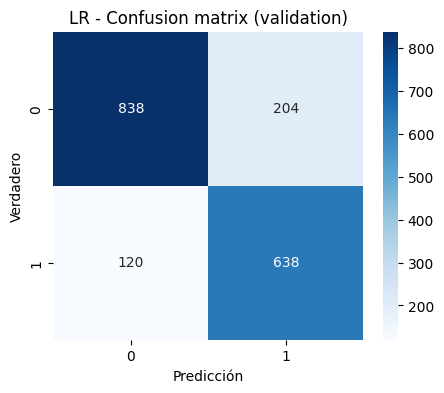

ROC-AUC (val): 0.8969


In [68]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported
from sklearn.base import BaseEstimator, TransformerMixin # For custom FrequencyEncoder
import numpy as np
import pandas as pd

# Asegurarse de tener matrices numpy densas
def to_dense(X):
    if hasattr(X, "toarray"):
        return X.toarray()
    return np.asarray(X)

# Assume X, y, X_train, X_val, X_test, y_train, y_val, y_test are already defined
# and df['y'] is mapped to 0/1 (from KIhW3-YJt-i0)

# Define column types based on initial split (X_train)
# Numerical columns (original)
initial_num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Categorical columns (original) - these are the ones still needing processing in X_train
initial_cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# --- Re-identify specific categorical groups based on original problem description ---
# The problem is that 'contact' was previously classified as binary based on nunique==2,
# but its values are not 'yes'/'no' and thus fail the 'binary_map'.

# Corrected groupings:
current_binary_cols = ['default', 'housing', 'loan'] # These are truly 'yes'/'no' binaries
current_ordinal_cols = ['education']
current_onehot_cols = ['marital', 'poutcome', 'contact'] # 'contact' moved here from binary
current_high_card_cols = ['job', 'month']

print("CT Binary:", current_binary_cols)
print("CT Ordinal:", current_ordinal_cols)
print("CT One-Hot:", current_onehot_cols)
print("CT High-Card:", current_high_card_cols)
print("CT Numerical (original):", initial_num_cols)

# --- Define Preprocessing Pipelines/Transformers for ColumnTransformer ---

# 1. Numerical Pipeline (Re-use logic from YWmEgQ1SuALK)
# Identify skewed numerical columns *from X_train*
skewness = X_train[initial_num_cols].skew().sort_values(ascending=False)
SKEW_THRESHOLD = 0.75
skewed_cols = skewness[skewness.abs() > SKEW_THRESHOLD].index.tolist()

log_cols = [c for c in skewed_cols if X_train[c].dropna().min() >= 0]
pt_cols  = [c for c in skewed_cols if c not in log_cols]
rest_num_cols = [c for c in initial_num_cols if c not in skewed_cols] # Original numericals not highly skewed

num_transformers = []

# Log1p pipeline for log_cols
if log_cols:
    log_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ])
    num_transformers.append(('log', log_pipe, log_cols))

# PowerTransformer pipeline for pt_cols
if pt_cols:
    pt_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('pt', PowerTransformer(method='yeo-johnson', standardize=False)), # standardize=False as scaler will do it
        ('scaler', StandardScaler())
    ])
    num_transformers.append(('pt', pt_pipe, pt_cols))

# Simple impute and scale for non-skewed numerical columns
if rest_num_cols:
    rest_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    num_transformers.append(('rest_num', rest_pipe, rest_num_cols))

# 2. Categorical Pipelines

# Binary pipeline: impute, map to 0/1
binary_map = {'yes':1, 'no':0}
binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('mapper', FunctionTransformer(lambda x: pd.Series(x.reshape(-1)).map(binary_map).astype(int).to_numpy().reshape(-1, 1), validate=False))
])

# Ordinal pipeline: impute, ordinal encode
edu_order = ['primary', 'secondary', 'tertiary'] # Define order
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord_enc', OrdinalEncoder(categories=[edu_order], handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int64))
])

# One-Hot pipeline: impute, one-hot encode
onehot_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')) # drop='first' for LR
])

# Frequency pipeline: impute, frequency encode
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_map = {}
    def fit(self, X, y=None):
        # X is typically a DataFrame passed by ColumnTransformer. Squeeze to get a Series.
        X_series = pd.Series(X.squeeze()).astype(str).fillna('missing')
        self.freq_map = X_series.value_counts(normalize=True).to_dict()
        return self
    def transform(self, X):
        X_series = pd.Series(X.squeeze()).astype(str).fillna('missing')
        # Use map for dictionary lookup and then fill any NaNs from unseen categories
        encoded = X_series.map(self.freq_map).fillna(0.0)
        return encoded.to_numpy().reshape(-1, 1)

frequency_pipe = Pipeline([
    ('freq_enc', FrequencyEncoder()) # Custom frequency encoder handles imputation
])

# --- Combine all transformers into a single ColumnTransformer ---
preprocessing_steps_ct = []

# Add numerical transformers
preprocessing_steps_ct.extend(num_transformers)

# Add categorical transformers
if current_binary_cols:
    for col in current_binary_cols:
        preprocessing_steps_ct.append((f'binary_{col}', binary_pipe, [col])) # Apply to [col]

if current_ordinal_cols:
    preprocessing_steps_ct.append(('ordinal', ordinal_pipe, current_ordinal_cols))

if current_onehot_cols:
    preprocessing_steps_ct.append(('onehot', onehot_pipe, current_onehot_cols))

# Change: Apply frequency_pipe to each high-cardinality column individually
if current_high_card_cols:
    for col in current_high_card_cols:
        preprocessing_steps_ct.append((f'frequency_{col}', frequency_pipe, [col])) # Apply to [col]


full_preprocessor = ColumnTransformer(
    transformers=preprocessing_steps_ct,
    remainder='drop',
    n_jobs=None # Changed from -1 to None to disable multiprocessing for debugging
)

# Fit and transform the data
X_train_processed_final = full_preprocessor.fit_transform(X_train)
X_val_processed_final = full_preprocessor.transform(X_val)
X_test_processed_final = full_preprocessor.transform(X_test)

# Convert to dense NumPy arrays for model training
Xtr = to_dense(X_train_processed_final)
Xv  = to_dense(X_val_processed_final)
Xt  = to_dense(X_test_processed_final)

ytr = np.asarray(y_train)
yv  = np.asarray(y_val)
yt  = np.asarray(y_test)

# Grid para Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'], # 'liblinear' also supports L2, 'saga' supports both L1/L2
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42) # Increase max_iter for convergence if needed

grid = GridSearchCV(lr, param_grid, scoring='f1', cv=cv, n_jobs=1, verbose=1) # Changed n_jobs to 1
grid.fit(Xtr, ytr)

print("Mejor combo (LR):", grid.best_params_)
best_lr = grid.best_estimator_

# Predicción en validación
y_val_pred = best_lr.predict(Xv)
print("Validación - Logistic Regression")
metrics_lr_val = show_metrics_and_cm(yv, y_val_pred, title="LR - Confusion matrix (validation)")

# ROC-AUC en validación
try:
    y_val_proba = best_lr.predict_proba(Xv)[:,1]
    roc_auc = roc_auc_score(yv, y_val_proba)
    print(f"ROC-AUC (val): {roc_auc:.4f}")
except Exception as e:
    print(f"Error calculating ROC-AUC: {e}")


Class weights: {np.int64(0): np.float64(0.8631713554987213), np.int64(1): np.float64(1.1883802816901408)}
Entrenando NN config: {'n_layers': 1, 'n_units': 32, 'dropout': 0.2, 'lr': 0.001}
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 (val): 0.8017
Entrenando NN config: {'n_layers': 1, 'n_units': 64, 'dropout': 0.2, 'lr': 0.001}
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 (val): 0.7985
Entrenando NN config: {'n_layers': 2, 'n_units': 32, 'dropout': 0.2, 'lr': 0.001}
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 (val): 0.7958
Entrenando NN config: {'n_layers': 2, 'n_units': 64, 'dropout': 0.2, 'lr': 0.001}
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 (val): 0.8002
Mejor F1 en validación (NN): 0.8017402113113735
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validación - Red Neuronal
Accuracy: 0.8228  Precision: 0.7579  Recall: 0.8509  F1: 0.8017

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1042
           1       0.76      0.8

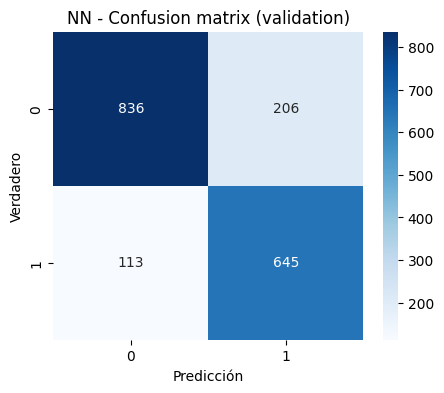

ROC-AUC (val): 0.9027405689282332


In [69]:
# Imports Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Calcular class_weight para el desbalance
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(ytr)
class_weights = dict(zip(classes, compute_class_weight(class_weight='balanced', classes=classes, y=ytr)))
print("Class weights:", class_weights)

# Definir constructor de modelos
def build_model(input_dim, n_layers=1, n_units=32, dropout=0.2, lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(n_layers):
        model.add(layers.Dense(n_units, activation='relu'))
        if dropout and dropout>0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

input_dim = Xtr.shape[1]

# Grid de búsqueda (manual, pequeño)
nn_configs = [
    {'n_layers':1, 'n_units':32, 'dropout':0.2, 'lr':1e-3},
    {'n_layers':1, 'n_units':64, 'dropout':0.2, 'lr':1e-3},
    {'n_layers':2, 'n_units':32, 'dropout':0.2, 'lr':1e-3},
    {'n_layers':2, 'n_units':64, 'dropout':0.2, 'lr':1e-3},
]

best_val_f1 = -1
best_nn = None
history_best = None

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0)

for cfg in nn_configs:
    tf.keras.backend.clear_session()
    model = build_model(input_dim, **cfg)
    print("Entrenando NN config:", cfg)
    hist = model.fit(
        Xtr, ytr,
        validation_data=(Xv, yv),
        epochs=80,
        batch_size=128,
        class_weight=class_weights,
        callbacks=[es, rlrop],
        verbose=0
    )
    # Predicciones en validación (umbral 0.5)
    yv_proba = model.predict(Xv).ravel()
    yv_pred = (yv_proba >= 0.5).astype(int)
    f1_val = f1_score(yv, yv_pred, zero_division=0)
    print(f"F1 (val): {f1_val:.4f}")
    if f1_val > best_val_f1:
        best_val_f1 = f1_val
        best_nn = model
        history_best = hist

print("Mejor F1 en validación (NN):", best_val_f1)
# Evaluar mejor NN en validación con métricas y CM
yv_proba = best_nn.predict(Xv).ravel()
yv_pred = (yv_proba >= 0.5).astype(int)
print("Validación - Red Neuronal")
metrics_nn_val = show_metrics_and_cm(yv, yv_pred, title="NN - Confusion matrix (validation)")
try:
    print("ROC-AUC (val):", roc_auc_score(yv, yv_proba))
except:
    pass
